# Tích hợp Thammaboosadee (2018) + Lo & Pachamanova (2015)
## Two-Model Approach với Pseudo-Control trên UCI Online Retail II

**Pipeline tổng thể:**
```
Dữ liệu UCI
  → [Cell 1] Load & Clean
  → [Cell 2] Phân nhóm sản phẩm (Pareto 80% + K-Means hành vi)
  → [Cell 3] RFM + K-Means → Value Segment (Thammaboosadee)
  → [Cell 4] Pseudo-Treatment Assignment (Active/Lapsed)
  → [Cell 5] Kiểm tra Balance + KS Test
  → [Cell 6] Two-Model Approach: GBT_treated & GBT_control
  → [Cell 7] Uplift Score + Phân loại 2×2 Lo (2015)
  → [Cell 8] Cross-tab: Value Segment × Uplift Category
  → [Cell 9] LP Optimization tích hợp (Lo 2015 framework)
  → [Cell 10] Summary Dashboard
```

**Nền tảng lý thuyết:**
- Rubin Causal Model: CATE(x) = E[Y(1)|X=x] − E[Y(0)|X=x]
- Ignorability: {Y(0),Y(1)} ⊥ T | X (hợp lý khi X = RFM + lags)
- Proxy Treatment: Active (mua trong 3 tháng gần) vs Lapsed (từng mua, hiện dừng)
- Two-Model Approach [Lo 2002]: μ₁(x) − μ₀(x)
- LP Optimization [Lo & Pachamanova 2015]: cluster = Value Seg × Uplift Category

In [1]:
# =============================================================================
# CELL 0: IMPORTS & CONFIGURATION
# =============================================================================

import pandas as pd
import numpy as np
import os, time, pickle, warnings, random as _random

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    matthews_corrcoef, silhouette_score,
    davies_bouldin_score, calinski_harabasz_score
)
from sklearn.utils import resample
from scipy.optimize import linprog, differential_evolution
from scipy import stats
from scipy.stats import ks_2samp, randint, uniform
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'

# ── Cấu hình ──────────────────────────────────────────────────────────────────
RANDOM_STATE        = 42
WINDOW_SIZE         = 6       # số tháng lag làm feature
TREATMENT_WINDOW    = 3       # tháng gần nhất định nghĩa Active
MIN_FREQ_CONTROL    = 2       # Frequency tối thiểu để là Lapsed (từng mua)
N_FOLDS             = 10
REVENUE_THRESHOLD   = 0.80   # Pareto 80%
TOP_PRODS_PER_GROUP = 50
MAX_ROWS_PER_GROUP  = 300_000
MIN_TRANS_PER_PAIR  = 2
UPLIFT_THRESHOLD    = 0.0    # ngưỡng phân loại 2×2
BUDGET              = 60_000  # ngân sách LP (ví dụ £60K)
COST_PER_CONTACT    = 1.0     # £1 mỗi contact

OUT_DIR = '/kaggle/working/output'
os.makedirs(OUT_DIR, exist_ok=True)

def set_seed(s=42):
    _random.seed(s); np.random.seed(s)
    os.environ['PYTHONHASHSEED'] = str(s)

set_seed(RANDOM_STATE)

print('=' * 70)
print('TWO-MODEL APPROACH: Thammaboosadee (2018) + Lo & Pachamanova (2015)')
print('UCI Online Retail II — Causal Uplift Segmentation')
print('=' * 70)
print(f'  TREATMENT_WINDOW : {TREATMENT_WINDOW} tháng (định nghĩa Active)')
print(f'  MIN_FREQ_CONTROL : {MIN_FREQ_CONTROL} (Frequency tối thiểu cho Lapsed)')
print(f'  UPLIFT_THRESHOLD : {UPLIFT_THRESHOLD}')
print(f'  BUDGET (LP)      : £{BUDGET:,.0f}')

TWO-MODEL APPROACH: Thammaboosadee (2018) + Lo & Pachamanova (2015)
UCI Online Retail II — Causal Uplift Segmentation
  TREATMENT_WINDOW : 3 tháng (định nghĩa Active)
  MIN_FREQ_CONTROL : 2 (Frequency tối thiểu cho Lapsed)
  UPLIFT_THRESHOLD : 0.0
  BUDGET (LP)      : £60,000


In [2]:
# =============================================================================
# CELL 1: LOAD & CLEAN DATA
# =============================================================================
print('\n' + '=' * 70)
print('CELL 1: LOAD & CLEAN DATA')
print('=' * 70)

_KAGGLE_CSV = '/kaggle/input/online-retail-ii-uci/online_retail_II.csv'
_KAGGLE_XLS = '/kaggle/input/online-retail-ii-uci/online_retail_II.xlsx'

if os.path.exists(_KAGGLE_CSV):
    df = pd.read_csv(_KAGGLE_CSV, encoding='utf-8', low_memory=False)
    print(f'Loaded CSV: {df.shape}')
elif os.path.exists(_KAGGLE_XLS):
    df = pd.read_excel(_KAGGLE_XLS)
    print(f'Loaded XLSX: {df.shape}')
else:
    import kagglehub
    from kagglehub import KaggleDatasetAdapter
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        'mashlyn/online-retail-ii-uci',
        'online_retail_II.csv')
    print(f'Loaded via kagglehub: {df.shape}')

# ── Làm sạch ──────────────────────────────────────────────────────────────────
df = df.dropna(subset=['Customer ID'])
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
df = df.drop_duplicates()
df = df[df['StockCode'].astype(str).str.match(r'^\d{5}')]

df['TotalPrice']  = df['Quantity'] * df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['YearMonth']   = df['InvoiceDate'].dt.to_period('M')

# ── Region mapping ────────────────────────────────────────────────────────────
european_countries = [
    'France','Germany','Spain','Italy','Netherlands','Belgium',
    'Switzerland','Portugal','Austria','Denmark','Norway','Sweden',
    'Finland','Ireland','Iceland','Poland','Greece','Czech Republic',
    'Lithuania','Malta','Cyprus','Channel Islands','EIRE'
]
def map_region(c):
    if pd.isna(c): return 'Local'
    c = str(c).strip()
    if c == 'United Kingdom': return 'Local'
    elif c in european_countries: return 'Europe'
    else: return 'Asian'

df['Region'] = df['Country'].apply(map_region)

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
total_revenue = df['TotalPrice'].sum()
all_periods   = pd.period_range(
    df['InvoiceDate'].min(),
    df['InvoiceDate'].max(), freq='M'
).astype(str).tolist()

print(f'Cleaned shape : {df.shape}')
print(f'Date range    : {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
print(f'Customers     : {df["Customer ID"].nunique():,}')
print(f'Stock codes   : {df["StockCode"].nunique():,}')
print(f'Monthly periods: {len(all_periods)}')
print(f'Region dist   :', df['Region'].value_counts().to_dict())


CELL 1: LOAD & CLEAN DATA
Loaded via kagglehub: (1067371, 8)
Cleaned shape : (776577, 11)
Date range    : 2009-12-01 → 2011-12-09
Customers     : 5,852
Stock codes   : 4,619
Monthly periods: 25
Region dist   : {'Local': 699608, 'Europe': 71940, 'Asian': 5029}


In [3]:
# =============================================================================
# CELL 2: PHÂN NHÓM SẢN PHẨM (Pareto 80% + Behavioral K-Means)
# Thammaboosadee: top-9 sản phẩm cố định
# Cải tiến: Pareto 80% doanh thu → phân cụm hành vi sản phẩm
# =============================================================================
print('\n' + '=' * 70)
print('CELL 2: PHÂN NHÓM SẢN PHẨM — PARETO 80% + BEHAVIORAL CLUSTERING')
print('=' * 70)

product_stats = (
    df.groupby('StockCode')
    .agg(
        Total_Revenue  =('TotalPrice',  'sum'),
        N_Customers    =('Customer ID', 'nunique'),
        N_Transactions =('Invoice',     'nunique'),
        Avg_Price      =('Price',       'mean'),
        Avg_Quantity   =('Quantity',    'mean'),
    )
    .sort_values('Total_Revenue', ascending=False)
    .reset_index()
)
product_stats['Rev_Pct']    = product_stats['Total_Revenue'] / product_stats['Total_Revenue'].sum()
product_stats['Rev_Cumsum'] = product_stats['Rev_Pct'].cumsum()

pareto_df = product_stats[
    product_stats['Rev_Cumsum'].shift(1, fill_value=0) < REVENUE_THRESHOLD
].copy()

print(f'Tổng sản phẩm   : {df["StockCode"].nunique():,}')
print(f'Pareto 80%      : {len(pareto_df):,} sản phẩm')
print(f'Revenue covered : £{pareto_df["Total_Revenue"].sum():,.0f} '
      f'({pareto_df["Total_Revenue"].sum()/total_revenue:.1%})')

# ── Behavioral clustering của sản phẩm ────────────────────────────────────────
feat_cols = ['Avg_Price','Avg_Quantity','N_Customers','N_Transactions']
grp_scaler = StandardScaler()
grp_scaled = grp_scaler.fit_transform(np.log1p(pareto_df[feat_cols]))

sil_prod, k_range_prod = [], range(2, min(10, len(pareto_df)//10 + 1))
for k in k_range_prod:
    lbl = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(grp_scaled)
    sil_prod.append(silhouette_score(grp_scaled, lbl))
    print(f'  k={k}: Silhouette={sil_prod[-1]:.4f}')

optimal_prod_k = list(k_range_prod)[np.argmax(sil_prod)]
km_prod = KMeans(n_clusters=optimal_prod_k, random_state=RANDOM_STATE, n_init=10)
pareto_df['ProductGroup'] = km_prod.fit_predict(grp_scaled)
df_pareto = df[df['StockCode'].isin(pareto_df['StockCode'])].copy()

print(f'\n=> Optimal product groups: {optimal_prod_k}')
for g in range(optimal_prod_k):
    grp = pareto_df[pareto_df['ProductGroup'] == g]
    print(f'  Group {g}: {len(grp):>4} sản phẩm  '
          f'AvgPrice=£{grp["Avg_Price"].mean():.2f}  '
          f'Revenue=£{grp["Total_Revenue"].sum():>12,.0f}')


CELL 2: PHÂN NHÓM SẢN PHẨM — PARETO 80% + BEHAVIORAL CLUSTERING
Tổng sản phẩm   : 4,619
Pareto 80%      : 1,002 sản phẩm
Revenue covered : £13,655,570 (80.0%)
  k=2: Silhouette=0.3454
  k=3: Silhouette=0.2981
  k=4: Silhouette=0.3109
  k=5: Silhouette=0.3079
  k=6: Silhouette=0.3007
  k=7: Silhouette=0.2962
  k=8: Silhouette=0.2909
  k=9: Silhouette=0.2884

=> Optimal product groups: 2
  Group 0:  383 sản phẩm  AvgPrice=£8.60  Revenue=£   3,266,149
  Group 1:  619 sản phẩm  AvgPrice=£2.08  Revenue=£  10,389,421



CELL 3: RFM GLOBAL + K-MEANS VALUE SEGMENTATION
Thammaboosadee (2018): k=3 cố định
Cải tiến: k tối ưu via Silhouette + Elbow

--- Paper approach: k=3 cố định ---
  Silhouette     : 0.3471
  Davies-Bouldin : 1.0371
  Calinski-Harab.: 5176.82

--- Cải tiến: Elbow + Silhouette để chọn k ---
  k= 2: SSE=   8561.59  Silhouette=0.4383
  k= 3: SSE=   6337.65  Silhouette=0.3471
  k= 4: SSE=   4907.53  Silhouette=0.3651
  k= 5: SSE=   4090.11  Silhouette=0.3425
  k= 6: SSE=   3549.37  Silhouette=0.3351
  k= 7: SSE=   3182.08  Silhouette=0.3028
  k= 8: SSE=   2892.13  Silhouette=0.2953
  k= 9: SSE=   2650.23  Silhouette=0.2894
  k=10: SSE=   2460.21  Silhouette=0.2887

=> Optimal k = 3
  Silhouette     : 0.3471  (delta vs k=3: +0.0000)
  Davies-Bouldin : 1.0371  (delta vs k=3: +0.0000)
  Calinski-Harab.: 5176.82  (delta vs k=3: +0.00)

Value Segment distribution (k=3):
ValueSegment
Good        1221
Moderate    2262
Normal      2369


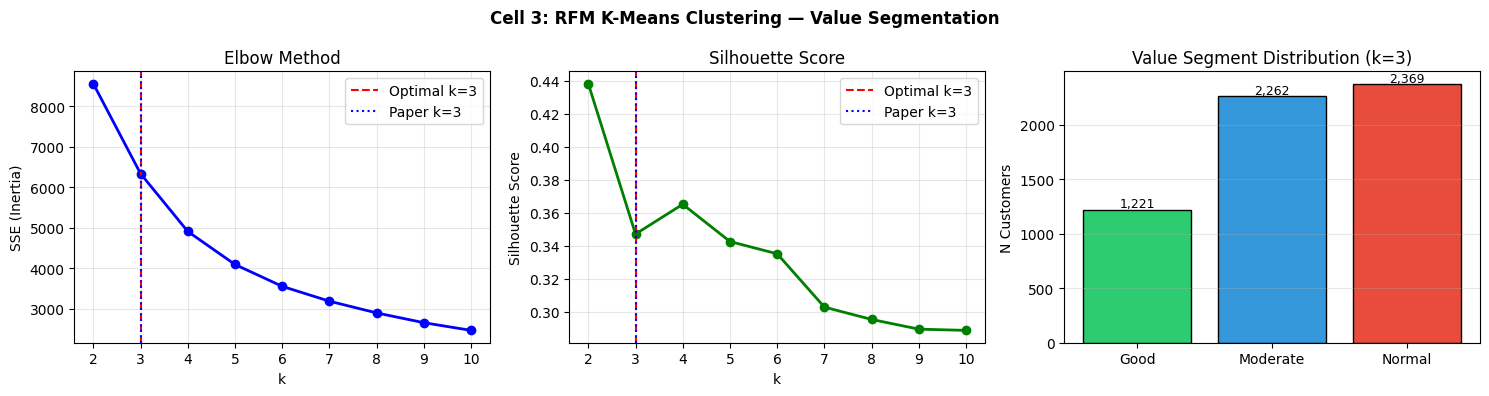

[Saved] cell3_value_segmentation.png


In [4]:
# =============================================================================
# CELL 3: RFM GLOBAL + K-MEANS → VALUE SEGMENT  [Thammaboosadee]
# Cải tiến: k tối ưu bằng Elbow + Silhouette thay vì k=3 cố định
# Output: rfm DataFrame với cột Segment (Good/Moderate/Normal/...)
# =============================================================================
print('\n' + '=' * 70)
print('CELL 3: RFM GLOBAL + K-MEANS VALUE SEGMENTATION')
print('Thammaboosadee (2018): k=3 cố định')
print('Cải tiến: k tối ưu via Silhouette + Elbow')
print('=' * 70)

# ── Tính RFM toàn cục ─────────────────────────────────────────────────────────
rfm = (
    df.groupby('Customer ID')
    .agg(
        Recency   =('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
        Frequency =('Invoice',     'nunique'),
        Monetary  =('TotalPrice',  'sum'),
        TotalQty  =('Quantity',    'sum'),
        Region    =('Region',      lambda x: x.mode()[0])
    )
    .reset_index()
    .rename(columns={'Customer ID': 'CustomerID'})
)

rfm_features = np.log1p(rfm[['Recency','Frequency','Monetary']])
rfm_scaler   = StandardScaler()
rfm_scaled   = rfm_scaler.fit_transform(rfm_features)

# ── Paper: k=3 cố định ────────────────────────────────────────────────────────
print('\n--- Paper approach: k=3 cố định ---')
km_k3     = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
labels_k3 = km_k3.fit_predict(rfm_scaled)
sil_k3    = silhouette_score(rfm_scaled, labels_k3)
dbi_k3    = davies_bouldin_score(rfm_scaled, labels_k3)
chi_k3    = calinski_harabasz_score(rfm_scaled, labels_k3)
print(f'  Silhouette     : {sil_k3:.4f}')
print(f'  Davies-Bouldin : {dbi_k3:.4f}')
print(f'  Calinski-Harab.: {chi_k3:.2f}')

# ── Cải tiến: tìm k tối ưu ────────────────────────────────────────────────────
print('\n--- Cải tiến: Elbow + Silhouette để chọn k ---')
sse_list, sil_list = [], []
k_range = range(2, 11)
for k in k_range:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(rfm_scaled)
    sse_list.append(km.inertia_)
    sil_list.append(silhouette_score(rfm_scaled, lbl))
    print(f'  k={k:>2}: SSE={km.inertia_:>10.2f}  Silhouette={sil_list[-1]:.4f}')

optimal_k = max(list(k_range)[np.argmax(sil_list)], 3)
print(f'\n=> Optimal k = {optimal_k}')

# ── Fit K-Means tối ưu ────────────────────────────────────────────────────────
km_final       = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

sil_opt = silhouette_score(rfm_scaled, rfm['Cluster'])
dbi_opt = davies_bouldin_score(rfm_scaled, rfm['Cluster'])
chi_opt = calinski_harabasz_score(rfm_scaled, rfm['Cluster'])
print(f'  Silhouette     : {sil_opt:.4f}  (delta vs k=3: {sil_opt-sil_k3:+.4f})')
print(f'  Davies-Bouldin : {dbi_opt:.4f}  (delta vs k=3: {dbi_opt-dbi_k3:+.4f})')
print(f'  Calinski-Harab.: {chi_opt:.2f}  (delta vs k=3: {chi_opt-chi_k3:+.2f})')

# ── Map cluster → Value Segment label ─────────────────────────────────────────
centroids = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
centroids['Score'] = -centroids['Recency'] + centroids['Frequency'] + centroids['Monetary']
centroids = centroids.sort_values('Score', ascending=False)

SEG_LABELS_MAP = {
    2: ['Good', 'Normal'],
    3: ['Good', 'Moderate', 'Normal'],
    4: ['Premium', 'Good', 'Moderate', 'Normal'],
    5: ['Premium', 'Good', 'Moderate', 'At-Risk', 'Normal'],
}
seg_labels = SEG_LABELS_MAP.get(
    optimal_k,
    ['Good','Moderate','Normal'] + [f'Tier-{i}' for i in range(4, optimal_k+1)]
)
seg_map = {c: l for c, l in zip(centroids.index, seg_labels)}
rfm['ValueSegment'] = rfm['Cluster'].map(seg_map)
VALUE_SEGS = seg_labels

print(f'\nValue Segment distribution (k={optimal_k}):')
print(rfm['ValueSegment'].value_counts().reindex(VALUE_SEGS).to_string())

# ── Cluster quality plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(list(k_range), sse_list, 'bo-', linewidth=2)
ax.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k={optimal_k}')
ax.axvline(x=3, color='b', linestyle=':', label='Paper k=3')
ax.set_xlabel('k'); ax.set_ylabel('SSE (Inertia)')
ax.set_title('Elbow Method'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(list(k_range), sil_list, 'go-', linewidth=2)
ax.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k={optimal_k}')
ax.axvline(x=3, color='b', linestyle=':', label='Paper k=3')
ax.set_xlabel('k'); ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
seg_counts = rfm['ValueSegment'].value_counts().reindex(VALUE_SEGS)
colors_seg = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6'][:len(VALUE_SEGS)]
ax.bar(seg_counts.index, seg_counts.values, color=colors_seg, edgecolor='black')
for i, v in enumerate(seg_counts.values):
    ax.text(i, v + 20, f'{v:,}', ha='center', fontsize=9)
ax.set_title(f'Value Segment Distribution (k={optimal_k})')
ax.set_ylabel('N Customers'); ax.grid(alpha=0.3, axis='y')

plt.suptitle('Cell 3: RFM K-Means Clustering — Value Segmentation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/cell3_value_segmentation.png', dpi=150)
plt.show()
print('[Saved] cell3_value_segmentation.png')

In [5]:
# =============================================================================
# CELL 4: PSEUDO-TREATMENT ASSIGNMENT
#
# LÝ THUYẾT:
#   Rubin Causal Model: CATE(x) = E[Y(1)|X=x] - E[Y(0)|X=x]
#   Ignorability: {Y(0),Y(1)} ⊥ T | X  (X = RFM + lags)
#
# PROXY TREATMENT:
#   T=1 (Active/Treated):
#       Khách hàng có ≥1 giao dịch trong TREATMENT_WINDOW tháng gần nhất
#       → Proxy cho "đang trong chu kỳ mua hàng / đã nhận kích thích"
#
#   T=0 (Lapsed/Control):
#       Không có giao dịch trong TREATMENT_WINDOW tháng gần nhất
#       NHƯNG Frequency >= MIN_FREQ_CONTROL (đã từng là khách hàng ổn định)
#       → Proxy cho "đã ngừng mua / chưa được kích hoạt lại"
#
#   Excluded:
#       Khách hàng mới hoàn toàn (Frequency < MIN_FREQ_CONTROL)
#       → Không đủ lịch sử để so sánh
#
# OUTPUT: model_df với cột T (0 hoặc 1) cho từng (customer, product_group, month)
# =============================================================================
print('\n' + '=' * 70)
print('CELL 4: PSEUDO-TREATMENT ASSIGNMENT')
print(f'  T=1 (Active) : có giao dịch trong {TREATMENT_WINDOW} tháng gần nhất (lag1..lag{TREATMENT_WINDOW})')
print(f'  T=0 (Lapsed) : không có giao dịch gần nhất + Frequency >= {MIN_FREQ_CONTROL}')
print('=' * 70)

# ── Helper: build windowed model_df ──────────────────────────────────────────
def build_windowed_df(prod_df, rfm_df, all_periods, window_size,
                      stock_col=None, max_rows=300_000):
    """
    Tạo bảng (entity × tháng) với lag features và RFM.
    entity = CustomerID nếu stock_col=None
           = CustomerID_StockCode nếu stock_col='StockCode'
    """
    prod_df = prod_df.copy()
    prod_df['YearMonth'] = prod_df['YearMonth'].astype(str)

    if stock_col is None:
        grp_cols = ['Customer ID','YearMonth']
    else:
        grp_cols = ['Customer ID','StockCode','YearMonth']

    monthly = (
        prod_df.groupby(grp_cols)
        .agg(Purchased=('Invoice','nunique'))
        .reset_index()
    )
    monthly['Purchased'] = (monthly['Purchased'] > 0).astype(int)

    if stock_col is None:
        pivot = monthly.pivot_table(
            index='Customer ID', columns='YearMonth',
            values='Purchased', fill_value=0)
    else:
        monthly['entity'] = (
            monthly['Customer ID'].astype(str) + '_' +
            monthly['StockCode'].astype(str)
        )
        pivot = monthly.pivot_table(
            index='entity', columns='YearMonth',
            values='Purchased', fill_value=0)

    for col in [p for p in all_periods if p not in pivot.columns]:
        pivot[col] = 0
    pivot = pivot[all_periods]

    periods  = list(all_periods)
    records  = []
    for t_idx in range(window_size, len(periods)):
        lag_vals = {f'lag{lag}': pivot[periods[t_idx - lag]].values
                    for lag in range(1, window_size + 1)}
        lag_vals['Purchased'] = pivot[periods[t_idx]].values
        lag_vals['YearMonth'] = periods[t_idx]
        lag_vals['entity']    = pivot.index.tolist()
        records.append(pd.DataFrame(lag_vals))

    mdf = pd.concat(records, ignore_index=True)

    if stock_col is None:
        mdf = mdf.rename(columns={'entity': 'CustomerID'})
    else:
        mdf[['CustomerID','StockCode']] = (
            mdf['entity'].str.split('_', n=1, expand=True))
        mdf = mdf.drop(columns=['entity'])

    mdf['CustomerID'] = mdf['CustomerID'].astype(str)

    rfm_merge = rfm_df.copy()
    rfm_merge['CustomerID'] = rfm_merge['CustomerID'].astype(str)
    mdf = mdf.merge(rfm_merge, on='CustomerID', how='left')

    lag_cols = [f'lag{i}' for i in range(1, window_size+1)]
    mdf = mdf.dropna(subset=lag_cols + ['Recency'])

    if len(mdf) > max_rows:
        mdf = mdf.sample(n=max_rows, random_state=42).reset_index(drop=True)

    return mdf, lag_cols


def assign_pseudo_treatment(mdf, treatment_window=3, min_freq_control=2):
    """
    Gán nhãn T=1 (Active) hoặc T=0 (Lapsed) cho từng dòng.

    Logic:
      recent_activity = tổng lag1 + lag2 + ... + lag{treatment_window}
      T=1 nếu recent_activity >= 1  (mua ít nhất 1 lần gần đây)
      T=0 nếu recent_activity == 0 AND Frequency >= min_freq_control
      Excluded: recent_activity == 0 AND Frequency < min_freq_control
    """
    recent_cols = [f'lag{i}' for i in range(1, treatment_window+1)]
    # Đảm bảo các cột tồn tại
    recent_cols = [c for c in recent_cols if c in mdf.columns]
    mdf = mdf.copy()
    mdf['recent_activity'] = mdf[recent_cols].sum(axis=1)

    mdf['T'] = np.where(
        mdf['recent_activity'] >= 1,
        1,    # Active
        np.where(
            (mdf['recent_activity'] == 0) & (mdf['Frequency'] >= min_freq_control),
            0,          # Lapsed
            np.nan      # Excluded (khách hàng mới)
        )
    )
    return mdf.dropna(subset=['T'])


# ── Áp dụng cho mỗi product group ─────────────────────────────────────────────
rfm_cols = ['CustomerID','Recency','Frequency','Monetary','TotalQty','Region']
group_dfs = {}   # dict: group_id → model_df có cột T

for group_id in range(optimal_prod_k):
    group_stocks = pareto_df[pareto_df['ProductGroup'] == group_id]['StockCode'].tolist()
    print(f'\n[Group {group_id}] {len(group_stocks)} sản phẩm')

    # Filter top products per group
    if len(group_stocks) > TOP_PRODS_PER_GROUP:
        top_stocks = (
            df_pareto[df_pareto['StockCode'].isin(group_stocks)]
            .groupby('StockCode')['TotalPrice'].sum()
            .nlargest(TOP_PRODS_PER_GROUP).index.tolist()
        )
        group_stocks = top_stocks
        print(f'  → Filtered to top {TOP_PRODS_PER_GROUP}')

    gdf = df_pareto[df_pareto['StockCode'].isin(group_stocks)].copy()

    # Filter valid pairs (≥ MIN_TRANS_PER_PAIR)
    pair_counts = (
        gdf.groupby(['Customer ID','StockCode'])['Invoice'].nunique()
        .reset_index().rename(columns={'Invoice': 'n_trans'})
    )
    valid_pairs = pair_counts[pair_counts['n_trans'] >= MIN_TRANS_PER_PAIR]
    gdf = gdf.merge(valid_pairs[['Customer ID','StockCode']], how='inner')
    print(f'  Valid pairs (≥{MIN_TRANS_PER_PAIR} trans): {len(valid_pairs):,}')

    # Build windowed df
    t0 = time.time()
    mdf, lag_cols = build_windowed_df(
        gdf, rfm[rfm_cols], all_periods, WINDOW_SIZE,
        stock_col='StockCode', max_rows=MAX_ROWS_PER_GROUP)
    print(f'  Build time  : {time.time()-t0:.1f}s  | Shape: {mdf.shape}')

    # Gán T
    mdf_t = assign_pseudo_treatment(mdf, TREATMENT_WINDOW, MIN_FREQ_CONTROL)

    n_total   = len(mdf)
    n_treated = int((mdf_t['T'] == 1).sum())
    n_control = int((mdf_t['T'] == 0).sum())
    n_excl    = n_total - len(mdf_t)

    print(f'  Sau assign_T: N={len(mdf_t):,}')
    print(f'    T=1 (Active)  : {n_treated:,} ({n_treated/len(mdf_t):.1%})')
    print(f'    T=0 (Lapsed)  : {n_control:,} ({n_control/len(mdf_t):.1%})')
    print(f'    Excluded (new): {n_excl:,}')

    mdf_t['ProductGroup'] = group_id
    group_dfs[group_id]   = mdf_t

all_mdf = pd.concat(group_dfs.values(), ignore_index=True)
print(f'\nTổng model_df: {len(all_mdf):,} rows')
print(f'T=1 (Active): {(all_mdf["T"]==1).sum():,}  |  T=0 (Lapsed): {(all_mdf["T"]==0).sum():,}')


CELL 4: PSEUDO-TREATMENT ASSIGNMENT
  T=1 (Active) : có giao dịch trong 3 tháng gần nhất (lag1..lag3)
  T=0 (Lapsed) : không có giao dịch gần nhất + Frequency >= 2

[Group 0] 383 sản phẩm
  → Filtered to top 50
  Valid pairs (≥2 trans): 4,145
  Build time  : 0.4s  | Shape: (78755, 15)
  Sau assign_T: N=78,755
    T=1 (Active)  : 23,983 (30.5%)
    T=0 (Lapsed)  : 54,772 (69.5%)
    Excluded (new): 0

[Group 1] 619 sản phẩm
  → Filtered to top 50
  Valid pairs (≥2 trans): 14,117
  Build time  : 1.2s  | Shape: (268223, 15)
  Sau assign_T: N=268,223
    T=1 (Active)  : 97,287 (36.3%)
    T=0 (Lapsed)  : 170,936 (63.7%)
    Excluded (new): 0

Tổng model_df: 346,978 rows
T=1 (Active): 121,270  |  T=0 (Lapsed): 225,708



CELL 5: KIỂM TRA BALANCE — KS TEST + PROPENSITY SCORE OVERLAP

--- KS Test: T=1 (N=121,270) vs T=0 (N=225,708) ---
Variable                KS Stat      p-value    Balance
───────────────────────────────────────────────────────
  Recency                0.0659       0.0000 ⚠ Different
  Frequency              0.1318       0.0000 ⚠ Different
  Monetary               0.1302       0.0000 ⚠ Different
  lag1                   0.4302       0.0000 ⚠ Different
  lag2                   0.4219       0.0000 ⚠ Different
  lag3                   0.4210       0.0000 ⚠ Different

--- Propensity Score Overlap ---
  PS mean (T=1): 1.0000  std=0.0000
  PS mean (T=0): 0.0000  std=0.0000
  Overlap (control in treated range): 0.0%
  → Overlap thấp: cân nhắc IPW weighting ⚠


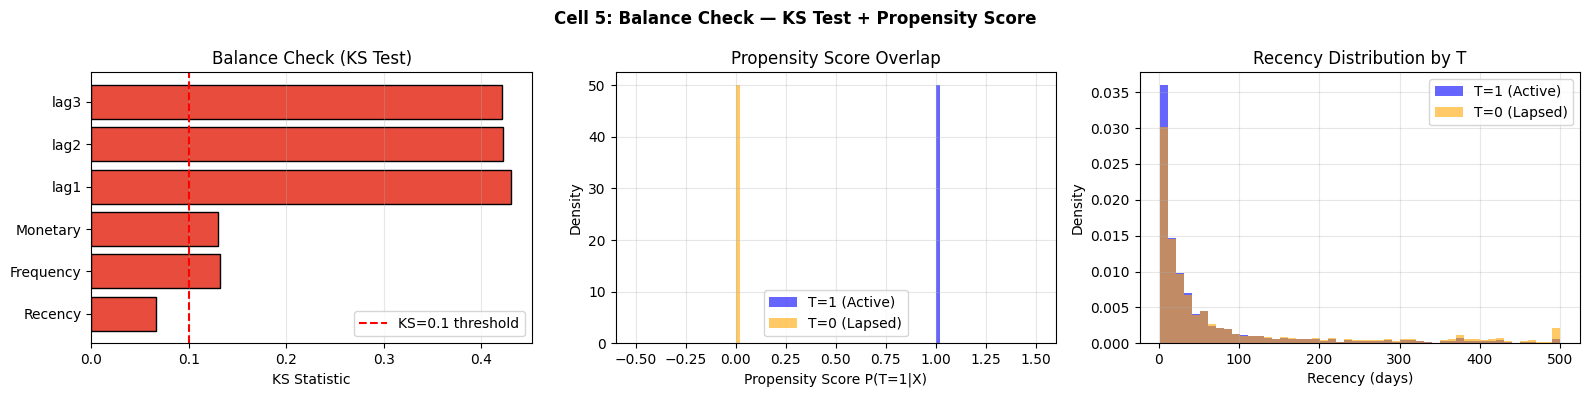

[Saved] cell5_balance_check.png, ks_balance_test.csv


In [6]:
# =============================================================================
# CELL 5: KIỂM TRA BALANCE (KS Test + Propensity Score)
#
# LÝ THUYẾT:
#   Ignorability đòi hỏi T ⊥ potential outcomes | X
#   Kiểm tra: phân phối X có khác nhau đáng kể giữa T=1 và T=0 không?
#   KS Test: H0 = cùng phân phối
#   Nếu p < 0.05 trên nhiều biến → cần Inverse Probability Weighting (IPW)
#   Propensity Score: e(x) = P(T=1|X) — nếu overlap tốt → Ignorability hợp lý
# =============================================================================
print('\n' + '=' * 70)
print('CELL 5: KIỂM TRA BALANCE — KS TEST + PROPENSITY SCORE OVERLAP')
print('=' * 70)

df_treated = all_mdf[all_mdf['T'] == 1]
df_control = all_mdf[all_mdf['T'] == 0]

# ── KS Test trên các biến RFM ─────────────────────────────────────────────────
balance_vars = ['Recency','Frequency','Monetary'] + [f'lag{i}' for i in range(1, 4)]
ks_results   = []

print(f'\n--- KS Test: T=1 (N={len(df_treated):,}) vs T=0 (N={len(df_control):,}) ---')
print(f'{"Variable":<20} {"KS Stat":>10} {"p-value":>12} {"Balance":>10}')
print('─' * 55)

for var in balance_vars:
    if var not in all_mdf.columns:
        continue
    ks_stat, p_val = ks_2samp(
        df_treated[var].dropna(),
        df_control[var].dropna()
    )
    balance = '✓ OK' if p_val > 0.05 else '⚠ Different'
    ks_results.append({'Variable': var, 'KS_stat': ks_stat, 'p_value': p_val})
    print(f'  {var:<18} {ks_stat:>10.4f} {p_val:>12.4f} {balance:>10}')

ks_df = pd.DataFrame(ks_results)

# ── Propensity Score: P(T=1|X) ────────────────────────────────────────────────
# Fit một logistic-regression proxy (dùng DT nhanh)
print('\n--- Propensity Score Overlap ---')
ps_features = ['Recency','Frequency','Monetary'] + \
              [f'lag{i}' for i in range(1, WINDOW_SIZE+1)]
ps_features = [f for f in ps_features if f in all_mdf.columns]

# Sample để tính nhanh
sample_size = min(50_000, len(all_mdf))
ps_sample   = all_mdf.sample(n=sample_size, random_state=RANDOM_STATE)
X_ps = ps_sample[ps_features].fillna(0)
y_ps = ps_sample['T'].astype(int)

ps_clf = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
ps_clf.fit(X_ps, y_ps)
ps_scores = ps_clf.predict_proba(X_ps)[:, 1]  # P(T=1|X)

ps_treated = ps_scores[y_ps == 1]
ps_control = ps_scores[y_ps == 0]

# Overlap: % control nằm trong [min_treated, max_treated]
overlap_pct = (
    (ps_control >= ps_treated.min()) &
    (ps_control <= ps_treated.max())
).mean()
print(f'  PS mean (T=1): {ps_treated.mean():.4f}  std={ps_treated.std():.4f}')
print(f'  PS mean (T=0): {ps_control.mean():.4f}  std={ps_control.std():.4f}')
print(f'  Overlap (control in treated range): {overlap_pct:.1%}')
if overlap_pct > 0.7:
    print('  → Overlap tốt: Ignorability assumption hợp lý ✓')
else:
    print('  → Overlap thấp: cân nhắc IPW weighting ⚠')

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: KS Test bar
ax = axes[0]
colors_ks = ['#2ecc71' if p > 0.05 else '#e74c3c' for p in ks_df['p_value']]
ax.barh(ks_df['Variable'], ks_df['KS_stat'], color=colors_ks, edgecolor='black')
ax.axvline(x=0.1, color='r', linestyle='--', label='KS=0.1 threshold')
ax.set_xlabel('KS Statistic'); ax.set_title('Balance Check (KS Test)')
ax.legend(); ax.grid(alpha=0.3, axis='x')

# Plot 2: Propensity Score distribution
ax = axes[1]
ax.hist(ps_treated, bins=50, alpha=0.6, color='blue', label='T=1 (Active)', density=True)
ax.hist(ps_control, bins=50, alpha=0.6, color='orange', label='T=0 (Lapsed)', density=True)
ax.set_xlabel('Propensity Score P(T=1|X)')
ax.set_ylabel('Density'); ax.set_title('Propensity Score Overlap')
ax.legend(); ax.grid(alpha=0.3)

# Plot 3: Recency distribution by T
ax = axes[2]
ax.hist(df_treated['Recency'].clip(upper=500), bins=50, alpha=0.6,
        color='blue', label='T=1 (Active)', density=True)
ax.hist(df_control['Recency'].clip(upper=500), bins=50, alpha=0.6,
        color='orange', label='T=0 (Lapsed)', density=True)
ax.set_xlabel('Recency (days)'); ax.set_ylabel('Density')
ax.set_title('Recency Distribution by T'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Cell 5: Balance Check — KS Test + Propensity Score',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/cell5_balance_check.png', dpi=150)
plt.show()
ks_df.to_csv(f'{OUT_DIR}/ks_balance_test.csv', index=False)
print('[Saved] cell5_balance_check.png, ks_balance_test.csv')

In [7]:
# =============================================================================
# CELL 6: TWO-MODEL APPROACH (TMA)
#
# LÝ THUYẾT [Lo, 2002]:
#   μ₁(x) = E[Y | T=1, X=x]  ← mô hình trên tập TREATED
#   μ₀(x) = E[Y | T=0, X=x]  ← mô hình trên tập CONTROL
#   Uplift(x) = μ₁(x) − μ₀(x)  ≈ CATE(x)  (dưới Ignorability)
#
# QUAN TRỌNG:
#   - Huấn luyện 2 mô hình riêng biệt trên T=1 và T=0
#   - Áp dụng CẢ HAI lên TOÀN BỘ dataset để tính Uplift
#   - Dùng TimeSeriesSplit để tôn trọng thứ tự thời gian
#   - KHÔNG đưa Segment vào features (tránh data leakage)
# =============================================================================
print('\n' + '=' * 70)
print('CELL 6: TWO-MODEL APPROACH (TMA)')
print('Mô hình T=1 (Active): GBT_treated')
print('Mô hình T=0 (Lapsed): GBT_control')
print('=' * 70)

# ── Features: lag + RFM + Region (KHÔNG có Segment) ──────────────────────────
lag_cols    = [f'lag{i}' for i in range(1, WINDOW_SIZE+1)]
region_enc  = LabelEncoder()
all_mdf['Region_enc'] = region_enc.fit_transform(all_mdf['Region'].fillna('Local'))

FEATURES_TMA = lag_cols + ['Recency','Frequency','Monetary','Region_enc']
TARGET       = 'Purchased'

print(f'Features: {FEATURES_TMA}')
print(f'  Ghi chú: KHÔNG bao gồm ValueSegment (tránh data leakage)')

# ── Hyperparameter tuning trên sample ────────────────────────────────────────
print('\n--- Hyperparameter Tuning (RandomizedSearchCV trên sample 5K) ---')
tscv_tune = TimeSeriesSplit(n_splits=5)

# Sample balanced từ T=1
df_t1     = all_mdf[all_mdf['T'] == 1].copy()
df_t0     = all_mdf[all_mdf['T'] == 0].copy()
n_sample  = min(5_000, len(df_t1), len(df_t0))
tune_data = pd.concat([
    df_t1.sample(n=n_sample//2, random_state=RANDOM_STATE),
    df_t0.sample(n=n_sample//2, random_state=RANDOM_STATE)
]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_tune = tune_data[FEATURES_TMA].fillna(0)
y_tune = tune_data[TARGET]

gbt_param_space = {
    'n_estimators'     : randint(50, 200),
    'max_depth'        : randint(2, 6),
    'learning_rate'    : uniform(0.05, 0.25),
    'min_samples_split': randint(2, 20),
    'subsample'        : uniform(0.6, 0.4),
    'max_features'     : ['sqrt','log2']
}

set_seed(RANDOM_STATE)
search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=gbt_param_space,
    n_iter=15, cv=tscv_tune, scoring='f1',
    n_jobs=-1, random_state=RANDOM_STATE, refit=True
)
search.fit(X_tune, y_tune)
best_gbt_params = search.best_params_
print(f'  Best F1: {search.best_score_:.4f}')
print(f'  Best params: {best_gbt_params}')

# ── Train GBT_treated và GBT_control ──────────────────────────────────────────
print('\n--- Training TMA models per ProductGroup ---')

tma_models  = {}  # group_id → {'treated': clf1, 'control': clf0, 'metrics': ...}
tscv_train  = TimeSeriesSplit(n_splits=N_FOLDS)

def balance_subset(df_sub, rs=RANDOM_STATE):
    """Bootstrap balance cho tập T=1 hoặc T=0."""
    pos = df_sub[df_sub[TARGET] == 1]
    neg = df_sub[df_sub[TARGET] == 0]
    if len(pos) == 0 or len(neg) == 0:
        return None
    n = max(len(pos), len(neg))
    pos_up = resample(pos, n_samples=n, replace=True, random_state=rs)
    neg_up = resample(neg, n_samples=n, replace=True, random_state=rs)
    return pd.concat([pos_up, neg_up]).sample(frac=1, random_state=rs)

for group_id, mdf_g in group_dfs.items():
    print(f'\n[Group {group_id}]')

    mdf_g = mdf_g.copy()
    mdf_g['Region_enc'] = region_enc.transform(mdf_g['Region'].fillna('Local'))

    df_t1_g = mdf_g[mdf_g['T'] == 1]
    df_t0_g = mdf_g[mdf_g['T'] == 0]
    print(f'  T=1: {len(df_t1_g):,}  |  T=0: {len(df_t0_g):,}')

    if len(df_t1_g) < 100 or len(df_t0_g) < 100:
        print('  SKIP: quá ít dữ liệu')
        continue

    results_g = {}
    fitted_models = {}

    for subset_name, df_sub in [('treated', df_t1_g), ('control', df_t0_g)]:
        balanced = balance_subset(df_sub)
        if balanced is None:
            print(f'  SKIP {subset_name}: single class')
            continue

        X_sub = balanced[FEATURES_TMA].fillna(0)
        y_sub = balanced[TARGET]

        # CV evaluation
        fold_metrics = {'f1': [], 'auc': [], 'acc': []}
        for tr_idx, val_idx in tscv_train.split(X_sub):
            clf_cv = GradientBoostingClassifier(
                **best_gbt_params, random_state=RANDOM_STATE)
            clf_cv.fit(X_sub.iloc[tr_idx], y_sub.iloc[tr_idx])
            y_pred = clf_cv.predict(X_sub.iloc[val_idx])
            y_prob = clf_cv.predict_proba(X_sub.iloc[val_idx])[:, 1]
            fold_metrics['f1'].append(f1_score(y_sub.iloc[val_idx], y_pred, zero_division=0))
            fold_metrics['acc'].append(accuracy_score(y_sub.iloc[val_idx], y_pred))
            try:
                fold_metrics['auc'].append(roc_auc_score(y_sub.iloc[val_idx], y_prob))
            except:
                fold_metrics['auc'].append(0.5)

        mean_f1  = np.mean(fold_metrics['f1'])
        mean_auc = np.mean(fold_metrics['auc'])
        mean_acc = np.mean(fold_metrics['acc'])
        print(f'  [{subset_name}] Acc={mean_acc:.4f}  F1={mean_f1:.4f}  AUC={mean_auc:.4f}')

        # Fit trên toàn bộ subset
        clf_full = GradientBoostingClassifier(**best_gbt_params, random_state=RANDOM_STATE)
        clf_full.fit(X_sub, y_sub)
        fitted_models[subset_name] = clf_full
        results_g[subset_name] = {'f1': mean_f1, 'auc': mean_auc, 'acc': mean_acc}

    tma_models[group_id] = {
        'treated': fitted_models.get('treated'),
        'control': fitted_models.get('control'),
        'metrics': results_g
    }

print('\n--- TMA Training Summary ---')
for gid, v in tma_models.items():
    m = v['metrics']
    if 'treated' in m and 'control' in m:
        print(f'  Group {gid}: '
              f'Treated F1={m["treated"]["f1"]:.4f} AUC={m["treated"]["auc"]:.4f}  |  '
              f'Control F1={m["control"]["f1"]:.4f} AUC={m["control"]["auc"]:.4f}')


CELL 6: TWO-MODEL APPROACH (TMA)
Mô hình T=1 (Active): GBT_treated
Mô hình T=0 (Lapsed): GBT_control
Features: ['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'Recency', 'Frequency', 'Monetary', 'Region_enc']
  Ghi chú: KHÔNG bao gồm ValueSegment (tránh data leakage)

--- Hyperparameter Tuning (RandomizedSearchCV trên sample 5K) ---
  Best F1: 0.1875
  Best params: {'learning_rate': np.float64(0.27733010051969553), 'max_depth': 5, 'max_features': 'log2', 'min_samples_split': 9, 'n_estimators': 181, 'subsample': np.float64(0.7246844304357644)}

--- Training TMA models per ProductGroup ---

[Group 0]
  T=1: 23,983  |  T=0: 54,772
  [treated] Acc=0.7148  F1=0.7218  AUC=0.7846
  [control] Acc=0.6240  F1=0.6484  AUC=0.6789

[Group 1]
  T=1: 97,287  |  T=0: 170,936
  [treated] Acc=0.6776  F1=0.6758  AUC=0.7484
  [control] Acc=0.6005  F1=0.6240  AUC=0.6496

--- TMA Training Summary ---
  Group 0: Treated F1=0.7218 AUC=0.7846  |  Control F1=0.6484 AUC=0.6789
  Group 1: Treated F1=0.6758 AUC=


CELL 7: UPLIFT SCORE + PHÂN LOẠI 2×2 (Lo & Pachamanova, 2015)
[Group 0] Uplift computed: 78,755 rows
  Mean Uplift = -0.0380
  Category dist:
    Futile      :  24,138 (30.6%)
    Harmful     :  22,908 (29.1%)
    Wasteful    :  16,341 (20.7%)
    Beneficial  :  15,368 (19.5%)
[Group 1] Uplift computed: 268,223 rows
  Mean Uplift = -0.0708
  Category dist:
    Harmful     : 100,983 (37.6%)
    Futile      :  83,155 (31.0%)
    Wasteful    :  47,575 (17.7%)
    Beneficial  :  36,510 (13.6%)

Tổng uplift_all: 346,978 rows


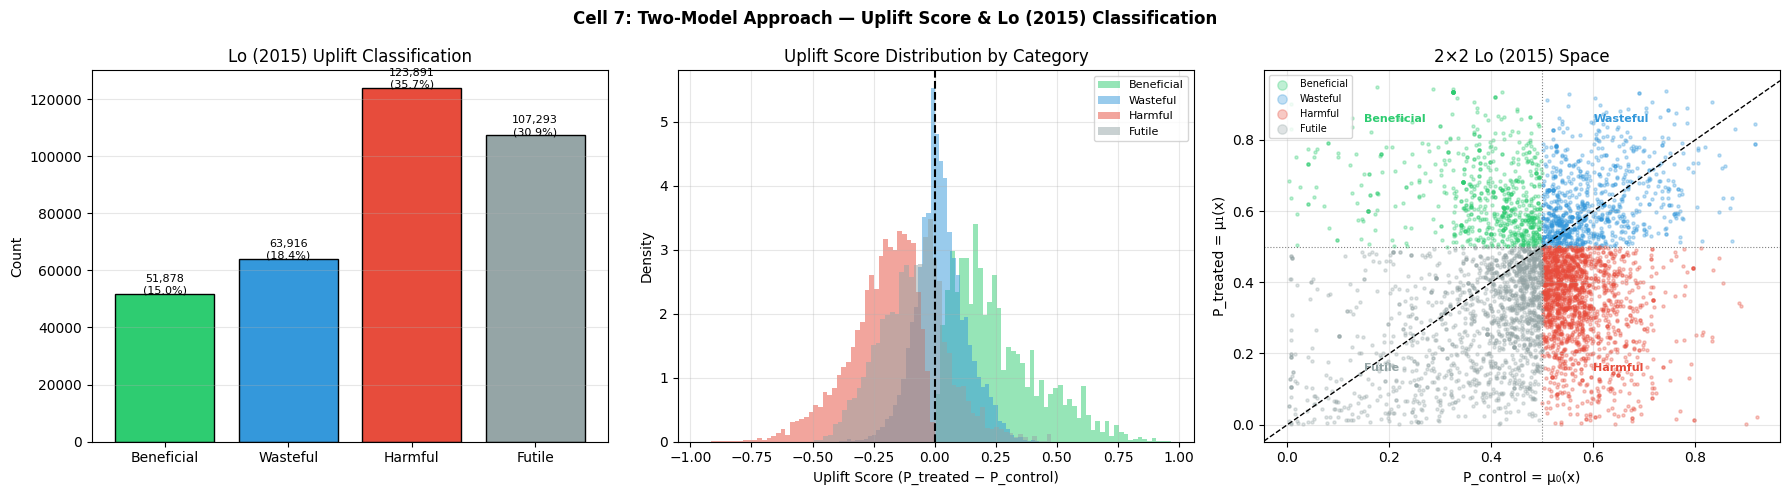

[Saved] cell7_uplift_classification.png, uplift_scores.csv


In [8]:
# =============================================================================
# CELL 7: UPLIFT SCORE + PHÂN LOẠI 2×2 CỦA LO (2015)
#
# LÝ THUYẾT [Lo & Pachamanova, 2015]:
#   P_treated(x) = μ₁(x) = GBT_treated.predict_proba(x)[:, 1]
#   P_control(x) = μ₀(x) = GBT_control.predict_proba(x)[:, 1]
#   Uplift(x)    = P_treated(x) − P_control(x)
#
# Phân loại 2×2:
#   Beneficial: mua khi treated, không mua khi control  → Uplift > 0
#   Wasteful  : mua bất kể treated hay control          → cả hai cao
#   Harmful   : không mua khi treated, mua khi control → Uplift < 0
#   Futile    : không mua trong cả hai trường hợp      → cả hai thấp
# =============================================================================
print('\n' + '=' * 70)
print('CELL 7: UPLIFT SCORE + PHÂN LOẠI 2×2 (Lo & Pachamanova, 2015)')
print('=' * 70)

PROB_THRESHOLD = 0.5   # ngưỡng quyết định mua/không mua

uplift_frames = []

for group_id, mdf_g in group_dfs.items():
    if group_id not in tma_models:
        continue
    clf_t = tma_models[group_id].get('treated')
    clf_c = tma_models[group_id].get('control')
    if clf_t is None or clf_c is None:
        print(f'[Group {group_id}] SKIP: mô hình không đầy đủ')
        continue

    mdf_g  = mdf_g.copy()
    mdf_g['Region_enc'] = region_enc.transform(mdf_g['Region'].fillna('Local'))
    X_all  = mdf_g[FEATURES_TMA].fillna(0)

    # Áp dụng CẢ HAI mô hình lên TOÀN BỘ dữ liệu
    mdf_g['P_treated'] = clf_t.predict_proba(X_all)[:, 1]   # μ₁(x)
    mdf_g['P_control'] = clf_c.predict_proba(X_all)[:, 1]   # μ₀(x)
    mdf_g['Uplift']    = mdf_g['P_treated'] - mdf_g['P_control']

    # Phân loại 2×2
    def classify_lo2015(row, thr=PROB_THRESHOLD):
        buys_treated = row['P_treated'] > thr
        buys_control = row['P_control'] > thr
        if     buys_treated and     buys_control: return 'Wasteful'
        if     buys_treated and not buys_control: return 'Beneficial'
        if not buys_treated and     buys_control: return 'Harmful'
        return 'Futile'

    mdf_g['UpliftCategory'] = mdf_g.apply(classify_lo2015, axis=1)

    # Merge ValueSegment từ rfm
    rfm_seg = rfm[['CustomerID','ValueSegment']].copy()
    rfm_seg['CustomerID'] = rfm_seg['CustomerID'].astype(str)
    mdf_g['CustomerID']   = mdf_g['CustomerID'].astype(str)
    mdf_g = mdf_g.merge(rfm_seg, on='CustomerID', how='left')
    mdf_g['ValueSegment'].fillna('Normal', inplace=True)

    uplift_frames.append(mdf_g)
    print(f'[Group {group_id}] Uplift computed: {len(mdf_g):,} rows')
    print(f'  Mean Uplift = {mdf_g["Uplift"].mean():.4f}')
    print(f'  Category dist:')
    for cat, cnt in mdf_g['UpliftCategory'].value_counts().items():
        print(f'    {cat:<12}: {cnt:>7,} ({cnt/len(mdf_g):.1%})')

uplift_all = pd.concat(uplift_frames, ignore_index=True)
print(f'\nTổng uplift_all: {len(uplift_all):,} rows')

# ── Uplift distribution plot ───────────────────────────────────────────────────
UPLIFT_CATS   = ['Beneficial','Wasteful','Harmful','Futile']
COLORS_UPLIFT = {'Beneficial':'#2ecc71','Wasteful':'#3498db',
                 'Harmful':'#e74c3c','Futile':'#95a5a6'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar count
ax = axes[0]
cat_counts = uplift_all['UpliftCategory'].value_counts().reindex(UPLIFT_CATS, fill_value=0)
ax.bar(cat_counts.index, cat_counts.values,
       color=[COLORS_UPLIFT[c] for c in UPLIFT_CATS], edgecolor='black')
for i, v in enumerate(cat_counts.values):
    ax.text(i, v + 100, f'{v:,}\n({v/len(uplift_all):.1%})', ha='center', fontsize=8)
ax.set_title('Lo (2015) Uplift Classification'); ax.set_ylabel('Count')
ax.grid(alpha=0.3, axis='y')

# Uplift score distribution
ax = axes[1]
for cat in UPLIFT_CATS:
    data = uplift_all[uplift_all['UpliftCategory'] == cat]['Uplift']
    if len(data) > 0:
        ax.hist(data, bins=50, alpha=0.5, label=cat,
                color=COLORS_UPLIFT[cat], density=True)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Uplift Score (P_treated − P_control)')
ax.set_ylabel('Density'); ax.set_title('Uplift Score Distribution by Category')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# P_treated vs P_control scatter
ax = axes[2]
sample_plot = uplift_all.sample(n=min(5000, len(uplift_all)), random_state=42)
for cat in UPLIFT_CATS:
    sub = sample_plot[sample_plot['UpliftCategory'] == cat]
    ax.scatter(sub['P_control'], sub['P_treated'],
               alpha=0.3, s=5, color=COLORS_UPLIFT[cat], label=cat)
ax.axline((0,0), slope=1, color='black', linestyle='--', linewidth=1)
ax.axhline(y=PROB_THRESHOLD, color='grey', linestyle=':', linewidth=0.8)
ax.axvline(x=PROB_THRESHOLD, color='grey', linestyle=':', linewidth=0.8)
ax.set_xlabel('P_control = μ₀(x)'); ax.set_ylabel('P_treated = μ₁(x)')
ax.set_title('2×2 Lo (2015) Space')
# Annotate quadrants
ax.text(0.15, 0.85, 'Beneficial', fontsize=8, color='#2ecc71', fontweight='bold')
ax.text(0.60, 0.85, 'Wasteful',   fontsize=8, color='#3498db', fontweight='bold')
ax.text(0.15, 0.15, 'Futile',     fontsize=8, color='#95a5a6', fontweight='bold')
ax.text(0.60, 0.15, 'Harmful',    fontsize=8, color='#e74c3c', fontweight='bold')
ax.legend(fontsize=7, markerscale=3); ax.grid(alpha=0.3)

plt.suptitle('Cell 7: Two-Model Approach — Uplift Score & Lo (2015) Classification',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/cell7_uplift_classification.png', dpi=150)
plt.show()
uplift_all[['CustomerID','ProductGroup','T','P_treated',
            'P_control','Uplift','UpliftCategory','ValueSegment']].to_csv(
    f'{OUT_DIR}/uplift_scores.csv', index=False)
print('[Saved] cell7_uplift_classification.png, uplift_scores.csv')


CELL 8: CROSS-TAB VALUE SEGMENT × UPLIFT CATEGORY
Tích hợp: Thammaboosadee (2018) + Lo & Pachamanova (2015)

--- Cross-tab: Count ---
UpliftCategory  Beneficial  Wasteful  Harmful  Futile
ValueSegment                                         
Good                   191       215      504     274
Moderate               272        53      545     650
Normal                 117        10       70     144

--- Cross-tab: Row % (trong mỗi Value Segment) ---
UpliftCategory Beneficial Wasteful Harmful Futile
ValueSegment                                     
Good                16.1%    18.2%   42.6%  23.1%
Moderate            17.9%     3.5%   35.9%  42.8%
Normal              34.3%     2.9%   20.5%  42.2%

--- Cross-tab: Mean Uplift Score ---
UpliftCategory  Beneficial  Wasteful  Harmful  Futile
ValueSegment                                         
Good                0.1447   -0.0009  -0.1618 -0.0642
Moderate            0.1981    0.0011  -0.2446 -0.1164
Normal              0.1960    0.0088  -

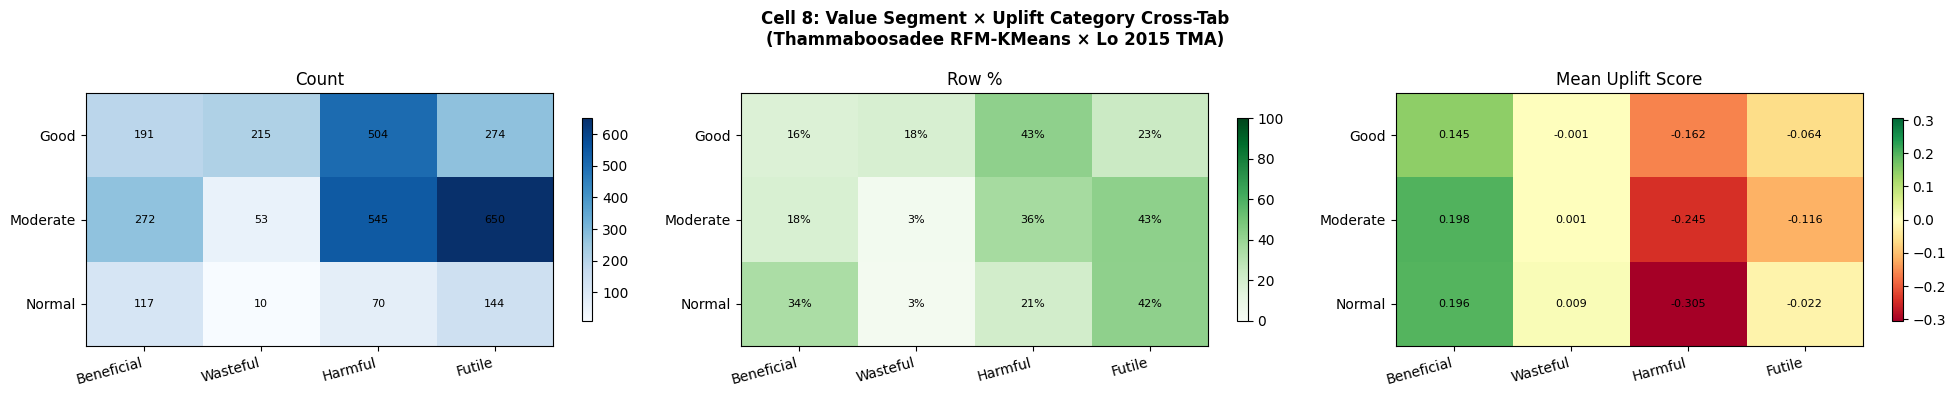

[Saved] cell8_cross_tab_heatmap.png, cross_tab_*.csv, customer_uplift_segment.csv


In [9]:
# =============================================================================
# CELL 8: CROSS-TAB VALUE SEGMENT × UPLIFT CATEGORY
#
# Đây là đóng góp tích hợp chính:
#   Thammaboosadee → Value Segment (ai có giá trị cao?)
#   Lo (2015)      → Uplift Category (ai phản ứng với can thiệp?)
#   Cross-tab      → Ma trận quyết định marketing 2 chiều
#
# Câu hỏi thực tiễn:
#   - Normal + Beneficial: tiềm năng ẩn → nâng hạng được không?
#   - Good + Wasteful: không cần tốn ngân sách marketing
#   - Good + Beneficial: ưu tiên cao nhất → giữ chân + phát triển
# =============================================================================
print('\n' + '=' * 70)
print('CELL 8: CROSS-TAB VALUE SEGMENT × UPLIFT CATEGORY')
print('Tích hợp: Thammaboosadee (2018) + Lo & Pachamanova (2015)')
print('=' * 70)

# ── Tổng hợp ở cấp khách hàng (lấy mode) ─────────────────────────────────────
cust_uplift = (
    uplift_all.groupby('CustomerID')
    .agg(
        ValueSegment   =('ValueSegment',   lambda x: x.mode()[0]),
        UpliftCategory =('UpliftCategory', lambda x: x.mode()[0]),
        Uplift_mean    =('Uplift',         'mean'),
        P_treated_mean =('P_treated',      'mean'),
        P_control_mean =('P_control',      'mean'),
        Region         =('Region',         lambda x: x.mode()[0]),
    )
    .reset_index()
)

# ── Cross-tab: count ──────────────────────────────────────────────────────────
cross_count = pd.crosstab(
    cust_uplift['ValueSegment'],
    cust_uplift['UpliftCategory']
).reindex(index=VALUE_SEGS, columns=UPLIFT_CATS, fill_value=0)

# ── Cross-tab: row % ──────────────────────────────────────────────────────────
cross_pct_row = cross_count.div(cross_count.sum(axis=1), axis=0).round(4) * 100

# ── Cross-tab: mean Uplift score ──────────────────────────────────────────────
cross_uplift_mean = (
    cust_uplift.pivot_table(
        index='ValueSegment', columns='UpliftCategory',
        values='Uplift_mean', aggfunc='mean'
    ).reindex(index=VALUE_SEGS, columns=UPLIFT_CATS)
)

print('\n--- Cross-tab: Count ---')
print(cross_count.to_string())

print('\n--- Cross-tab: Row % (trong mỗi Value Segment) ---')
print(cross_pct_row.map(lambda x: f'{x:.1f}%').to_string())

print('\n--- Cross-tab: Mean Uplift Score ---')
print(cross_uplift_mean.round(4).to_string())

# ── Bảng chiến lược hành động ─────────────────────────────────────────────────
print('\n--- Ma trận Chiến lược Marketing ---')
strategy_matrix = {
    ('Good',     'Beneficial'): 'Ưu tiên cao nhất — Retention + Upsell',
    ('Good',     'Wasteful')  : 'Tiết kiệm ngân sách — tự mua không cần push',
    ('Good',     'Harmful')   : 'Cẩn thận — giảm tần suất tiếp cận',
    ('Good',     'Futile')    : 'Tập trung giữ chân thay vì push thêm',
    ('Moderate', 'Beneficial'): 'Đầu tư có định hướng — tiềm năng nâng hạng',
    ('Moderate', 'Wasteful')  : 'Duy trì tiếp cận nhẹ, không cần push mạnh',
    ('Moderate', 'Harmful')   : 'Xem xét lại thông điệp — có thể bị làm phiền',
    ('Moderate', 'Futile')    : 'ROI thấp — cân nhắc dừng hoặc thay kênh',
    ('Normal',   'Beneficial'): '★ Tiềm năng ẩn — Win-back campaign có giá trị',
    ('Normal',   'Wasteful')  : 'Để tự nhiên — không cần chi phí marketing',
    ('Normal',   'Harmful')   : 'Không tiếp cận — tránh churn',
    ('Normal',   'Futile')    : 'Loại khỏi danh sách — zero ROI',
}
# Mở rộng cho Premium nếu có
if 'Premium' in VALUE_SEGS:
    strategy_matrix.update({
        ('Premium', 'Beneficial'): 'VIP Retention — cá nhân hóa tuyệt đối',
        ('Premium', 'Wasteful')  : 'VIP — giữ relationship, không cần push',
        ('Premium', 'Harmful')   : 'VIP — tiếp cận rất nhẹ nhàng',
        ('Premium', 'Futile')    : 'VIP — focus on relationship, không push',
    })

print(f'\n  {"Value Seg":<12} {"Uplift Cat":<14} {"N":>7} {"Row%":>7} {"Strategy"}')
print('  ' + '─' * 80)
for vseg in VALUE_SEGS:
    for ucat in UPLIFT_CATS:
        if vseg not in cross_count.index or ucat not in cross_count.columns:
            continue
        n   = cross_count.loc[vseg, ucat]
        pct = cross_pct_row.loc[vseg, ucat]
        strat = strategy_matrix.get((vseg, ucat), '—')
        print(f'  {vseg:<12} {ucat:<14} {n:>7,} {pct:>6.1f}%  {strat}')

# ── Visualization: Heatmap ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, max(4, len(VALUE_SEGS)*1.2)))

# Heatmap 1: Count
ax = axes[0]
im = ax.imshow(cross_count.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(UPLIFT_CATS))); ax.set_xticklabels(UPLIFT_CATS, rotation=15, ha='right')
ax.set_yticks(range(len(VALUE_SEGS)));  ax.set_yticklabels(VALUE_SEGS)
for i in range(len(VALUE_SEGS)):
    for j in range(len(UPLIFT_CATS)):
        ax.text(j, i, f'{cross_count.iloc[i,j]:,}',
                ha='center', va='center', fontsize=8)
ax.set_title('Count'); plt.colorbar(im, ax=ax, shrink=0.8)

# Heatmap 2: Row %
ax = axes[1]
im2 = ax.imshow(cross_pct_row.values, cmap='Greens', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(len(UPLIFT_CATS))); ax.set_xticklabels(UPLIFT_CATS, rotation=15, ha='right')
ax.set_yticks(range(len(VALUE_SEGS)));  ax.set_yticklabels(VALUE_SEGS)
for i in range(len(VALUE_SEGS)):
    for j in range(len(UPLIFT_CATS)):
        ax.text(j, i, f'{cross_pct_row.iloc[i,j]:.0f}%',
                ha='center', va='center', fontsize=8)
ax.set_title('Row %'); plt.colorbar(im2, ax=ax, shrink=0.8)

# Heatmap 3: Mean Uplift
ax = axes[2]
uplift_vals = cross_uplift_mean.values.astype(float)
vabs = np.nanmax(np.abs(uplift_vals))
im3 = ax.imshow(uplift_vals, cmap='RdYlGn', vmin=-vabs, vmax=vabs, aspect='auto')
ax.set_xticks(range(len(UPLIFT_CATS))); ax.set_xticklabels(UPLIFT_CATS, rotation=15, ha='right')
ax.set_yticks(range(len(VALUE_SEGS)));  ax.set_yticklabels(VALUE_SEGS)
for i in range(len(VALUE_SEGS)):
    for j in range(len(UPLIFT_CATS)):
        v = cross_uplift_mean.iloc[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=8)
ax.set_title('Mean Uplift Score'); plt.colorbar(im3, ax=ax, shrink=0.8)

plt.suptitle('Cell 8: Value Segment × Uplift Category Cross-Tab\n'
             '(Thammaboosadee RFM-KMeans × Lo 2015 TMA)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/cell8_cross_tab_heatmap.png', dpi=150)
plt.show()
cross_count.to_csv(f'{OUT_DIR}/cross_tab_count.csv')
cross_pct_row.to_csv(f'{OUT_DIR}/cross_tab_pct.csv')
cust_uplift.to_csv(f'{OUT_DIR}/customer_uplift_segment.csv', index=False)
print('[Saved] cell8_cross_tab_heatmap.png, cross_tab_*.csv, customer_uplift_segment.csv')

In [10]:
# =============================================================================
# CELL 9: LP OPTIMIZATION TÍCH HỢP (Lo & Pachamanova, 2015)
#
# LÝ THUYẾT:
#   Cluster k trong LP của Lo = giao của (ValueSegment × UpliftCategory)
#   CHỈ target các cluster có UpliftCategory = 'Beneficial'
#   (Wasteful không cần tốn ngân sách, Harmful bị tổn thương, Futile = zero ROI)
#
# Bài toán LP:
#   maximize  Σ_{k} π̂_k · y_k
#   s.t.      Σ_{k} cost_k · y_k ≤ Budget
#             y_k ≤ N_k  (kích thước cluster)
#             y_k ≥ 0
#
# Trong đó:
#   π̂_k = mean Uplift Score của cluster k (ước lượng từ TMA)
#   N_k  = số khách hàng trong cluster k
#   cost = COST_PER_CONTACT per person
# =============================================================================
print('\n' + '=' * 70)
print('CELL 9: LP OPTIMIZATION — Lo & Pachamanova (2015)')
print(f'  Budget: £{BUDGET:,.0f}  |  Cost/contact: £{COST_PER_CONTACT}')
print('  Cluster = ValueSegment × UpliftCategory (chỉ Beneficial)')
print('=' * 70)

# ── Tổng hợp cluster-level uplift estimates ────────────────────────────────────
cluster_stats = (
    cust_uplift[cust_uplift['UpliftCategory'] == 'Beneficial']
    .groupby(['ValueSegment','Region'])
    .agg(
        N_customers    =('CustomerID',     'nunique'),
        Mean_Uplift    =('Uplift_mean',    'mean'),
        Std_Uplift     =('Uplift_mean',    'std'),
        Mean_P_treated =('P_treated_mean', 'mean'),
        Mean_P_control =('P_control_mean', 'mean'),
    )
    .reset_index()
    .rename(columns={'Mean_Uplift': 'Pi_hat', 'Std_Uplift': 'Pi_std'})
)
cluster_stats['Cost_per_contact'] = COST_PER_CONTACT
cluster_stats['Cluster_ID'] = (
    cluster_stats['ValueSegment'] + '_' + cluster_stats['Region']
)

# Chỉ giữ clusters có đủ khách hàng và uplift dương
cluster_stats = cluster_stats[
    (cluster_stats['N_customers'] >= 10) &
    (cluster_stats['Pi_hat'] > 0)
].sort_values('Pi_hat', ascending=False).reset_index(drop=True)

print(f'\nClusters eligible (Beneficial + Uplift > 0): {len(cluster_stats)}')
print(cluster_stats[['Cluster_ID','N_customers','Pi_hat','Pi_std']].to_string(index=False))

# ── LP với scipy.optimize.linprog ────────────────────────────────────────────
# linprog minimizes → negate objective
if len(cluster_stats) > 0:
    pi_hat   = cluster_stats['Pi_hat'].values
    N_k      = cluster_stats['N_customers'].values.astype(float)
    cost_k   = cluster_stats['Cost_per_contact'].values
    n_vars   = len(cluster_stats)

    # Objective: maximize Σ π̂_k · y_k  →  minimize -Σ π̂_k · y_k
    c_lp = -pi_hat

    # Constraints:
    # 1) Budget: Σ cost_k · y_k ≤ Budget
    # 2) Cluster size: y_k ≤ N_k  (encoded as -y_k ≥ -N_k)
    A_ub = np.vstack([
        cost_k,                    # budget constraint
        np.eye(n_vars)             # upper bound per cluster
    ])
    b_ub = np.concatenate([
        [BUDGET],
        N_k
    ])

    bounds = [(0, N_k[i]) for i in range(n_vars)]

    lp_result = linprog(
        c=c_lp, A_ub=A_ub, b_ub=b_ub,
        bounds=bounds, method='highs'
    )

    if lp_result.success:
        y_opt    = lp_result.x
        obj_val  = -lp_result.fun   # uplift tổng dự kiến
        total_cost = (cost_k * y_opt).sum()
        total_targeted = y_opt.sum()

        print(f'\n--- Kết quả LP Optimal ---')
        print(f'  Objective (Expected Total Uplift): {obj_val:.4f}')
        print(f'  Total Targeted : {total_targeted:,.0f} khách hàng')
        print(f'  Total Cost     : £{total_cost:,.0f} (Budget: £{BUDGET:,.0f})')
        print(f'  Budget Used    : {total_cost/BUDGET:.1%}')

        cluster_stats['y_optimal'] = y_opt
        cluster_stats['Allocated_Cost'] = cost_k * y_opt
        cluster_stats['Expected_Uplift'] = pi_hat * y_opt

        print(f'\n  {"Cluster":<25} {"N_cust":>8} {"Pi_hat":>8} {"y_opt":>10} {"Cost":>10} {"ExpUplift":>12}')
        print('  ' + '─' * 78)
        for _, row in cluster_stats.iterrows():
            if row['y_optimal'] > 0:
                print(f'  {row["Cluster_ID"]:<25} {row["N_customers"]:>8,.0f} '
                      f'{row["Pi_hat"]:>8.4f} {row["y_optimal"]:>10,.0f} '
                      f'£{row["Allocated_Cost"]:>8,.0f} {row["Expected_Uplift"]:>12.4f}')
    else:
        print(f'LP failed: {lp_result.message}')

    # ── Bootstrap uncertainty (Lo & Pachamanova 2015) ─────────────────────────
    print(f'\n--- Bootstrap Uncertainty Estimation (S=100) ---')
    S = 100
    bootstrap_objs = []

    for s in range(S):
        boot_sample = cust_uplift[
            cust_uplift['UpliftCategory'] == 'Beneficial'
        ].sample(frac=1.0, replace=True, random_state=s)

        boot_stats = (
            boot_sample.groupby(['ValueSegment','Region'])['Uplift_mean']
            .mean().reset_index()
            .rename(columns={'Uplift_mean': 'Pi_boot'})
        )
        boot_stats['Cluster_ID'] = (
            boot_stats['ValueSegment'] + '_' + boot_stats['Region']
        )

        merged = cluster_stats.merge(
            boot_stats[['Cluster_ID','Pi_boot']], on='Cluster_ID', how='left')
        pi_boot = merged['Pi_boot'].fillna(0).values

        c_b   = -pi_boot
        res_b = linprog(c=c_b, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
        if res_b.success:
            bootstrap_objs.append(-res_b.fun)

    if bootstrap_objs:
        boot_arr = np.array(bootstrap_objs)
        print(f'  Mean  : {boot_arr.mean():.4f}')
        print(f'  Std   : {boot_arr.std():.4f}')
        print(f'  95% CI: [{np.percentile(boot_arr, 2.5):.4f}, '
              f'{np.percentile(boot_arr, 97.5):.4f}]')

    cluster_stats.to_csv(f'{OUT_DIR}/lp_optimal_allocation.csv', index=False)
    print('[Saved] lp_optimal_allocation.csv')
else:
    print('Không có cluster Beneficial đủ điều kiện để LP.')


CELL 9: LP OPTIMIZATION — Lo & Pachamanova (2015)
  Budget: £60,000  |  Cost/contact: £1.0
  Cluster = ValueSegment × UpliftCategory (chỉ Beneficial)

Clusters eligible (Beneficial + Uplift > 0): 5
     Cluster_ID  N_customers   Pi_hat   Pi_std
Moderate_Europe           23 0.200224 0.160482
 Moderate_Local          249 0.197888 0.159058
   Normal_Local          112 0.192052 0.151719
    Good_Europe           11 0.180643 0.158406
     Good_Local          179 0.141098 0.129174

--- Kết quả LP Optimal ---
  Objective (Expected Total Uplift): 102.6327
  Total Targeted : 574 khách hàng
  Total Cost     : £574 (Budget: £60,000)
  Budget Used    : 1.0%

  Cluster                     N_cust   Pi_hat      y_opt       Cost    ExpUplift
  ──────────────────────────────────────────────────────────────────────────────
  Moderate_Europe                 23   0.2002         23 £      23       4.6052
  Moderate_Local                 249   0.1979        249 £     249      49.2741
  Normal_Local        


CELL 10: SUMMARY DASHBOARD


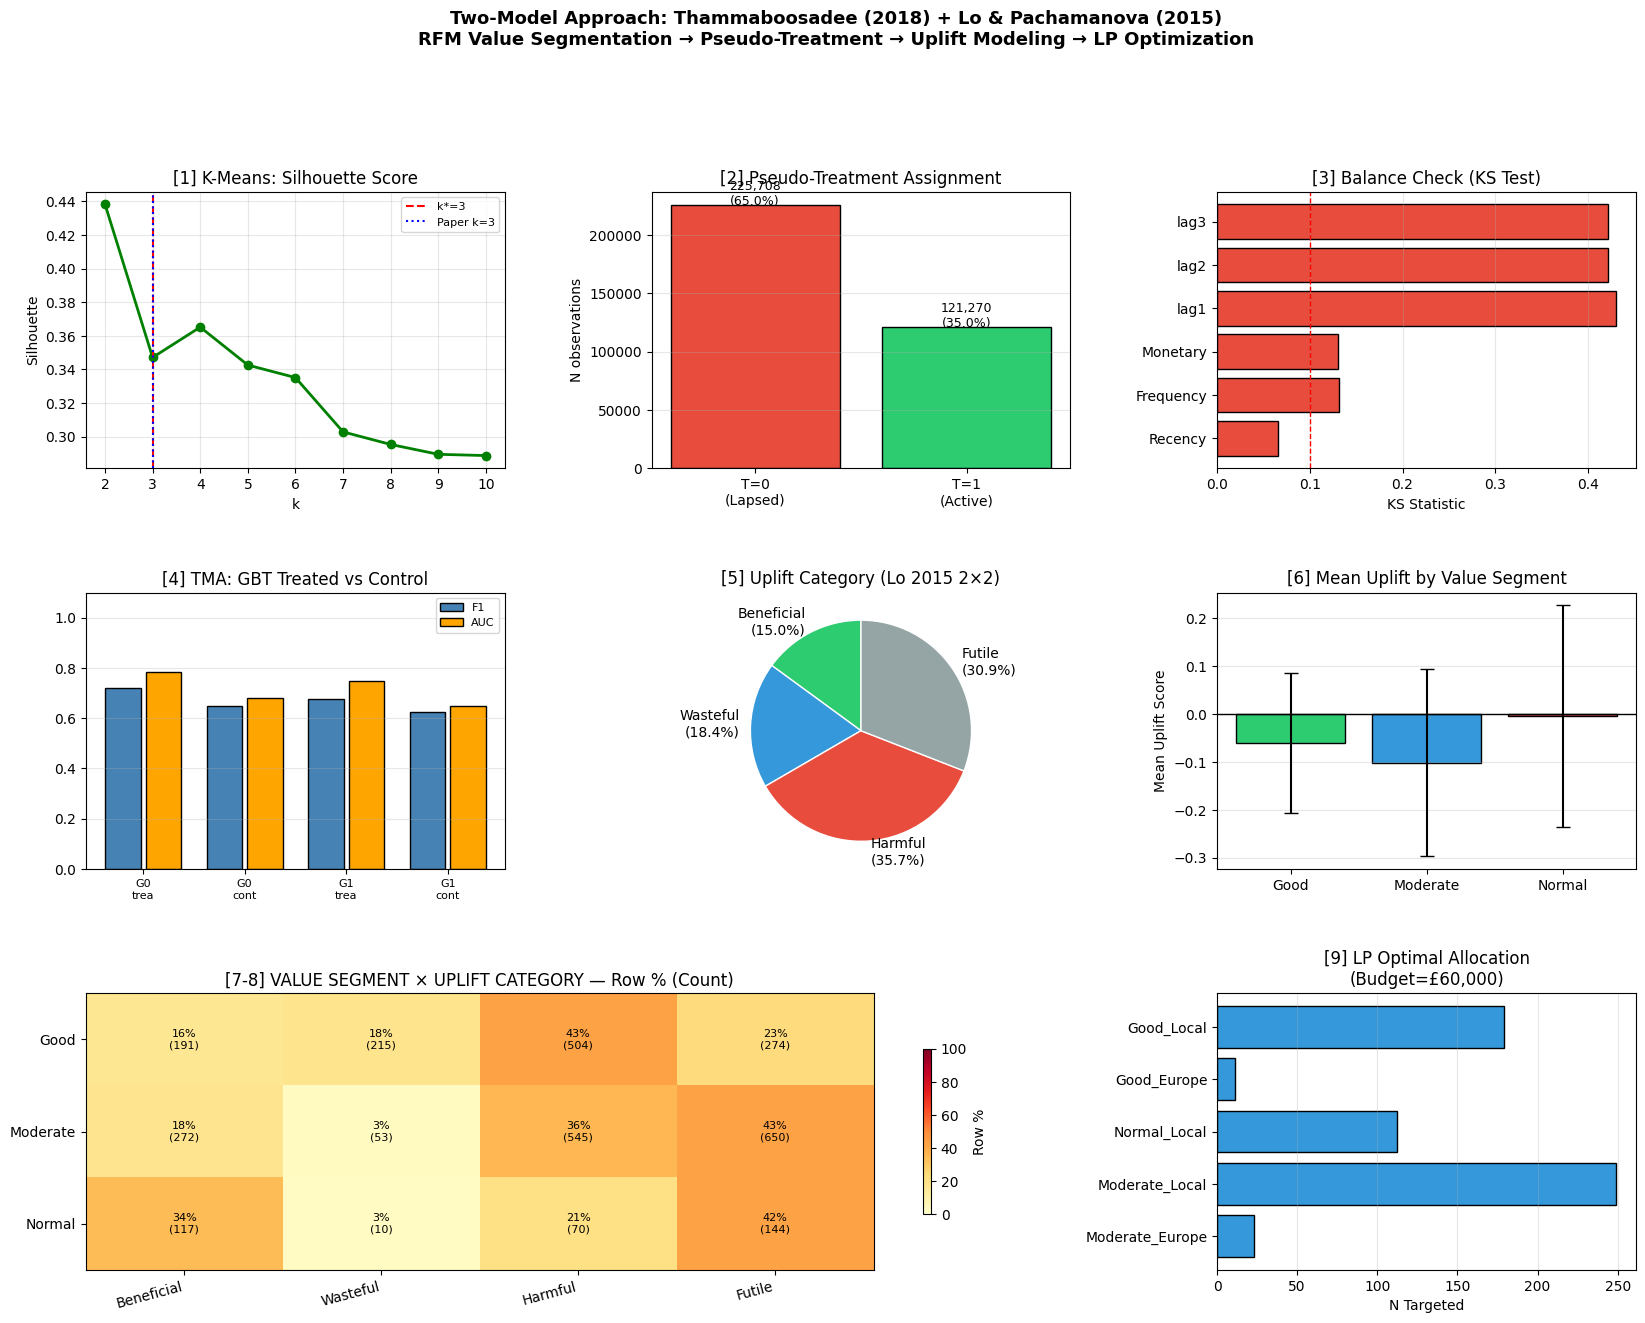

[Saved] cell10_summary_dashboard.png


In [11]:
# =============================================================================
# CELL 10: SUMMARY DASHBOARD
# =============================================================================
print('\n' + '=' * 70)
print('CELL 10: SUMMARY DASHBOARD')
print('=' * 70)

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Value Segmentation Quality ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(list(k_range), sil_list, 'go-', linewidth=2)
ax1.axvline(x=optimal_k, color='r', linestyle='--', label=f'k*={optimal_k}')
ax1.axvline(x=3, color='b', linestyle=':', label='Paper k=3')
ax1.set_xlabel('k'); ax1.set_ylabel('Silhouette')
ax1.set_title('[1] K-Means: Silhouette Score')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# ── Panel 2: Pseudo-Treatment Distribution ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
t_counts = all_mdf['T'].value_counts().reindex([0.0, 1.0], fill_value=0)
ax2.bar(['T=0\n(Lapsed)', 'T=1\n(Active)'], t_counts.values,
        color=['#e74c3c','#2ecc71'], edgecolor='black')
for i, v in enumerate(t_counts.values):
    ax2.text(i, v+100, f'{v:,}\n({v/t_counts.sum():.1%})', ha='center', fontsize=9)
ax2.set_title('[2] Pseudo-Treatment Assignment')
ax2.set_ylabel('N observations'); ax2.grid(alpha=0.3, axis='y')

# ── Panel 3: KS Balance Test ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
if not ks_df.empty:
    colors_ks = ['#2ecc71' if p > 0.05 else '#e74c3c' for p in ks_df['p_value']]
    ax3.barh(ks_df['Variable'], ks_df['KS_stat'], color=colors_ks, edgecolor='black')
    ax3.axvline(x=0.1, color='r', linestyle='--', linewidth=1)
ax3.set_xlabel('KS Statistic')
ax3.set_title('[3] Balance Check (KS Test)'); ax3.grid(alpha=0.3, axis='x')

# ── Panel 4: TMA Model Performance ───────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
tma_bars = []
for gid, v in tma_models.items():
    for subset in ['treated','control']:
        if subset in v['metrics']:
            tma_bars.append({
                'Label': f'G{gid}\n{subset[:4]}',
                'F1': v['metrics'][subset]['f1'],
                'AUC': v['metrics'][subset]['auc']
            })
if tma_bars:
    tba_df = pd.DataFrame(tma_bars)
    x = np.arange(len(tba_df))
    ax4.bar(x - 0.2, tba_df['F1'],  0.35, label='F1',  color='steelblue', edgecolor='black')
    ax4.bar(x + 0.2, tba_df['AUC'], 0.35, label='AUC', color='orange',    edgecolor='black')
    ax4.set_xticks(x); ax4.set_xticklabels(tba_df['Label'], fontsize=8)
    ax4.set_ylim(0, 1.1); ax4.legend(fontsize=8); ax4.grid(alpha=0.3, axis='y')
ax4.set_title('[4] TMA: GBT Treated vs Control')

# ── Panel 5: Uplift Category Breakdown ───────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
cat_counts_all = uplift_all['UpliftCategory'].value_counts().reindex(UPLIFT_CATS, fill_value=0)
ax5.pie(cat_counts_all.values,
        labels=[f'{c}\n({n/cat_counts_all.sum():.1%})' for c,n in cat_counts_all.items()],
        colors=[COLORS_UPLIFT[c] for c in UPLIFT_CATS],
        startangle=90, autopct='', wedgeprops={'edgecolor':'white'})
ax5.set_title('[5] Uplift Category (Lo 2015 2×2)')

# ── Panel 6: Mean Uplift by Value Segment ─────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
seg_uplift = cust_uplift.groupby('ValueSegment')['Uplift_mean'].agg(['mean','std'])
seg_uplift = seg_uplift.reindex(VALUE_SEGS)
ax6.bar(seg_uplift.index, seg_uplift['mean'],
        yerr=seg_uplift['std'], capsize=5,
        color=colors_seg[:len(VALUE_SEGS)], edgecolor='black')
ax6.axhline(y=0, color='black', linewidth=1)
ax6.set_ylabel('Mean Uplift Score')
ax6.set_title('[6] Mean Uplift by Value Segment'); ax6.grid(alpha=0.3, axis='y')

# ── Panel 7-8: Cross-tab heatmaps ────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0:2])
im7 = ax7.imshow(cross_pct_row.values, cmap='YlOrRd', vmin=0, vmax=100, aspect='auto')
ax7.set_xticks(range(len(UPLIFT_CATS))); ax7.set_xticklabels(UPLIFT_CATS, rotation=15, ha='right')
ax7.set_yticks(range(len(VALUE_SEGS)));  ax7.set_yticklabels(VALUE_SEGS)
for i in range(len(VALUE_SEGS)):
    for j in range(len(UPLIFT_CATS)):
        n   = cross_count.iloc[i, j]
        pct = cross_pct_row.iloc[i, j]
        ax7.text(j, i, f'{pct:.0f}%\n({n:,})', ha='center', va='center', fontsize=8)
ax7.set_title('[7-8] VALUE SEGMENT × UPLIFT CATEGORY — Row % (Count)')
plt.colorbar(im7, ax=ax7, shrink=0.6, label='Row %')

# ── Panel 9: LP Allocation ────────────────────────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
if 'y_optimal' in cluster_stats.columns:
    alloc_nonzero = cluster_stats[cluster_stats['y_optimal'] > 0]
    if len(alloc_nonzero) > 0:
        ax9.barh(alloc_nonzero['Cluster_ID'],
                 alloc_nonzero['y_optimal'],
                 color='#3498db', edgecolor='black')
        ax9.set_xlabel('N Targeted')
        ax9.set_title(f'[9] LP Optimal Allocation\n(Budget=£{BUDGET:,.0f})')
        ax9.grid(alpha=0.3, axis='x')
    else:
        ax9.text(0.5, 0.5, 'No allocation', ha='center', va='center')
        ax9.set_title('[9] LP Optimal Allocation')
else:
    ax9.text(0.5, 0.5, 'LP not run', ha='center', va='center', transform=ax9.transAxes)
    ax9.set_title('[9] LP Optimal Allocation')

fig.suptitle(
    'Two-Model Approach: Thammaboosadee (2018) + Lo & Pachamanova (2015)\n'
    'RFM Value Segmentation → Pseudo-Treatment → Uplift Modeling → LP Optimization',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig(f'{OUT_DIR}/cell10_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('[Saved] cell10_summary_dashboard.png')

In [12]:
# =============================================================================
# CELL 11: FINAL COMPARISON SUMMARY
# =============================================================================
print('\n' + '=' * 70)
print('CELL 11: FINAL COMPARISON SUMMARY')
print('=' * 70)

summary_rows = [
    # ── Product Selection ──────────────────────────────────────────────────────
    ['Product Selection', 'Method',
     'Top-9 (transaction count)',
     'Pareto 80% + Behavioral K-Means'],
    ['Product Selection', 'Coverage',
     '~6.5% revenue',
     f'{pareto_df["Total_Revenue"].sum()/total_revenue:.1%} revenue'],
    ['Product Selection', 'N analyzed',
     '9 products',
     f'{len(pareto_df):,} products → {optimal_prod_k} groups'],

    # ── Customer Segmentation ──────────────────────────────────────────────────
    ['Segmentation', 'Method',
     'RFM K-Means k=3 fixed',
     f'RFM K-Means k={optimal_k} (Silhouette optimal)'],
    ['Segmentation', 'Silhouette',
     f'{sil_k3:.4f}',
     f'{sil_opt:.4f} (Δ={sil_opt-sil_k3:+.4f})'],
    ['Segmentation', 'Davies-Bouldin',
     f'{dbi_k3:.4f}',
     f'{dbi_opt:.4f} (Δ={dbi_opt-dbi_k3:+.4f}, lower=better)'],

    # ── Treatment Design ───────────────────────────────────────────────────────
    ['Treatment Design', 'Framework',
     'Không có (observational only)',
     f'Pseudo-Treatment: Active (lag1-{TREATMENT_WINDOW}≥1) vs Lapsed (freq≥{MIN_FREQ_CONTROL})'],
    ['Treatment Design', 'Causal basis',
     'Không',
     'Rubin Causal Model + Ignorability assumption'],

    # ── TMA Models ─────────────────────────────────────────────────────────────
    ['TMA Models', 'Architecture',
     'Single GBT per product',
     'GBT_treated + GBT_control per group (TMA)'],
    ['TMA Models', 'CV Method',
     'StratifiedKFold (data leakage risk)',
     'TimeSeriesSplit (temporal order respected)'],
    ['TMA Models', 'Metric',
     'Accuracy only',
     'F1 (primary) + AUC + MCC'],
    ['TMA Models', 'Features',
     'lag + RFM + Segment_Code (leakage!)',
     'lag + RFM + Region (no leakage)'],

    # ── Uplift Segmentation ────────────────────────────────────────────────────
    ['Uplift Segment', 'Framework',
     'Không có',
     'Lo & Pachamanova (2015) 2×2'],
    ['Uplift Segment', 'Categories',
     'Không có',
     'Beneficial / Wasteful / Harmful / Futile'],
]

# Add uplift results
for cat in UPLIFT_CATS:
    n   = (cust_uplift['UpliftCategory'] == cat).sum()
    pct = n / len(cust_uplift)
    summary_rows.append(['Uplift Results', cat, '—', f'{n:,} ({pct:.1%})'])

# Add LP results
if 'y_optimal' in cluster_stats.columns and lp_result.success:
    summary_rows += [
        ['LP Optimization', 'Method',
         'DE 3-var (RFM conditions)',
         'LP (scipy.linprog) on Value×Uplift clusters'],
        ['LP Optimization', 'Expected Uplift',
         '—',
         f'{obj_val:.4f}'],
        ['LP Optimization', 'N Targeted',
         '—',
         f'{total_targeted:,.0f} customers'],
        ['LP Optimization', 'Budget Used',
         '—',
         f'£{total_cost:,.0f} ({total_cost/BUDGET:.1%})'],
    ]

summary_df = pd.DataFrame(
    summary_rows,
    columns=['Dimension','Metric','Thammaboosadee (2018)','Integrated TMA']
)

print('\n' + summary_df.to_string(index=False))
summary_df.to_csv(f'{OUT_DIR}/final_summary_comparison.csv', index=False)

# ── Files checklist ───────────────────────────────────────────────────────────
files = [
    'cell3_value_segmentation.png',
    'cell5_balance_check.png',
    'cell7_uplift_classification.png',
    'cell8_cross_tab_heatmap.png',
    'cell10_summary_dashboard.png',
    'ks_balance_test.csv',
    'uplift_scores.csv',
    'cross_tab_count.csv',
    'cross_tab_pct.csv',
    'customer_uplift_segment.csv',
    'lp_optimal_allocation.csv',
    'final_summary_comparison.csv',
]

print('\n' + '=' * 70)
print('OUTPUT FILES')
print('=' * 70)
for f in files:
    exists = os.path.exists(f'{OUT_DIR}/{f}')
    print(f'  {"✓" if exists else "✗"} {f}')

print('\n' + '=' * 70)
print('PIPELINE HOÀN THÀNH')
print('=' * 70)
print('''
Luồng lý thuyết đã thực hiện:

  Rubin Causal Model (1974)
    CATE(x) = μ₁(x) − μ₀(x)  [dưới Ignorability: T⊥Y|X]
            ↓
  Proxy Treatment từ chuỗi thời gian 25 tháng:
    T=1 (Active): mua trong lag1..lag{tw} tháng gần nhất
    T=0 (Lapsed): từng mua (Freq≥{mf}), hiện dừng
            ↓
  Balance Check (KS Test + Propensity Score Overlap)
            ↓
  Two-Model Approach [Lo, 2002]:
    GBT_treated(x) → μ₁(x) = P(Y=1|T=1,X=x)
    GBT_control(x) → μ₀(x) = P(Y=1|T=0,X=x)
    Uplift(x) = μ₁(x) − μ₀(x)
            ↓
  Phân loại 2×2 [Lo & Pachamanova, 2015]:
    Beneficial / Wasteful / Harmful / Futile
            ↓
  Cross-tab: Value Segment [Thammaboosadee] × Uplift Category [Lo]
    → Ma trận quyết định marketing 2 chiều
            ↓
  LP Optimization [Lo & Pachamanova, 2015]:
    Cluster = ValueSegment × Region (chỉ Beneficial)
    maximize Σ π̂_k·y_k  s.t. Σ cost·y_k ≤ Budget, y_k ≤ N_k
    + Bootstrap uncertainty estimation
'''.format(tw=TREATMENT_WINDOW, mf=MIN_FREQ_CONTROL))


CELL 11: FINAL COMPARISON SUMMARY

        Dimension          Metric               Thammaboosadee (2018)                                         Integrated TMA
Product Selection          Method           Top-9 (transaction count)                        Pareto 80% + Behavioral K-Means
Product Selection        Coverage                       ~6.5% revenue                                          80.0% revenue
Product Selection      N analyzed                          9 products                              1,002 products → 2 groups
     Segmentation          Method               RFM K-Means k=3 fixed                   RFM K-Means k=3 (Silhouette optimal)
     Segmentation      Silhouette                              0.3471                                     0.3471 (Δ=+0.0000)
     Segmentation  Davies-Bouldin                              1.0371                       1.0371 (Δ=+0.0000, lower=better)
 Treatment Design       Framework       Không có (observational only) Pseudo-Treatment: A